# Intensity Transformations & Filtering Spatial Domain

## Thresholding

Threshold value: 0


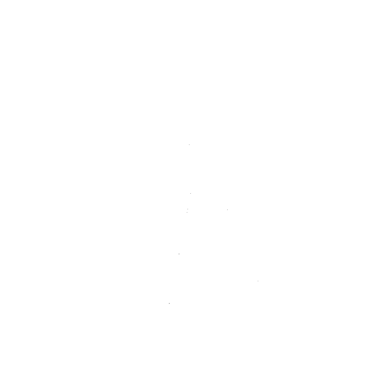

Threshold value: 50


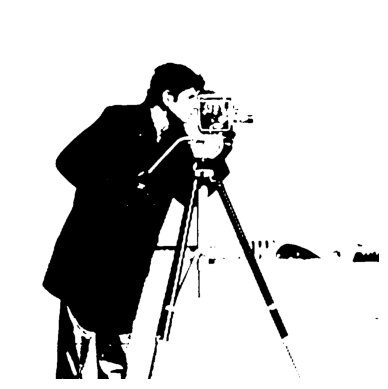

Threshold value: 100


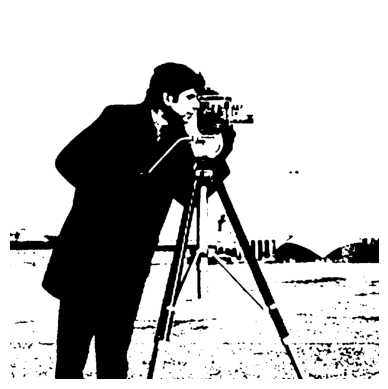

Threshold value: 150


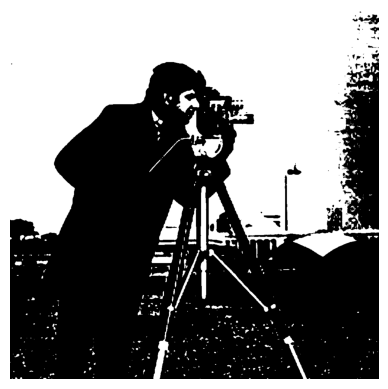

Threshold value: 200


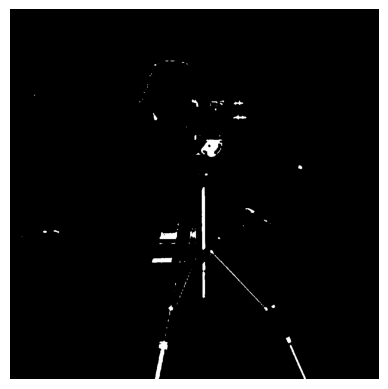

In [4]:
import cv2
import matplotlib.pyplot as plt

# Load the image in grayscale
image_path = r'C:\Users\daian\Downloads\cameraman.png'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

# Apply thresholding with different threshold values
for threshold_value in threshold_values:
    ret_thresh_value, thresh_img = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)

    print(f"Threshold value: {threshold_value}")
    plt.imshow(thresh_img, cmap='gray')
    plt.axis('off')
    plt.show()

## Histograms

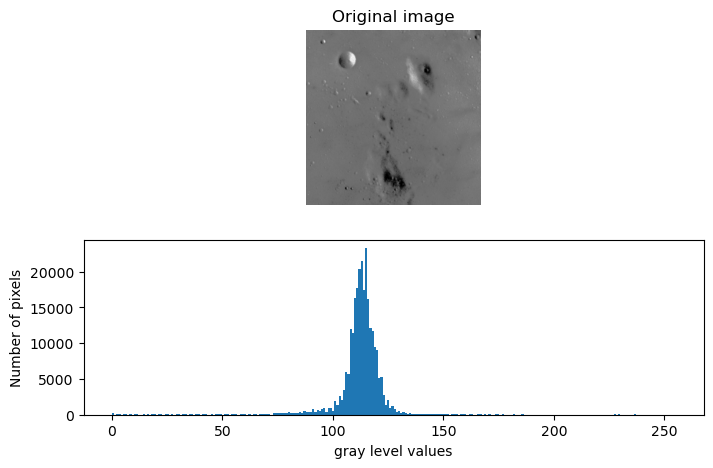

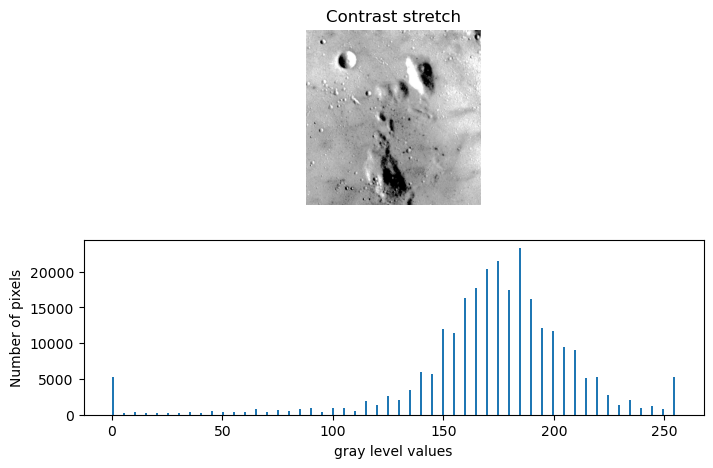

In [3]:
# Task#2: Histogram Processing

# Step#1: Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data
from skimage import exposure

# Step#2: Load moon image
img = data.moon()

# Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

# Step#4: Display the image with its histogram of (step#2)  and (step#3)
fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap = 'gray')
plt.axis('off')
plt.title('Original image')

fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap = 'gray')
plt.axis('off')
plt.title('Contrast stretch')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

# Tasks:

Task1: Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram

Task2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.

Task3: Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching


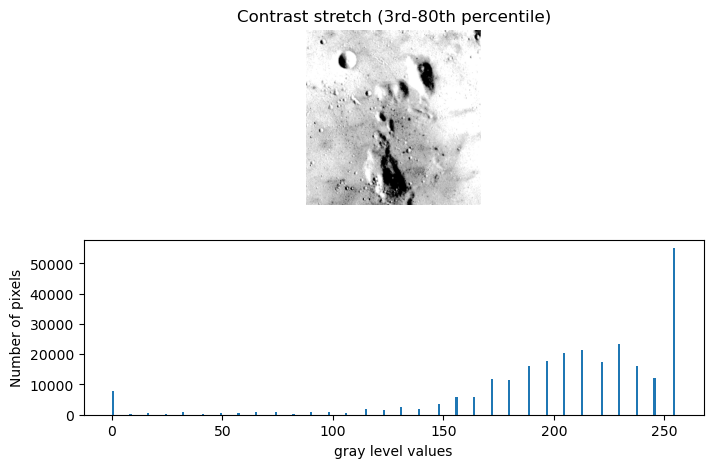

In [4]:
# Task1: Rescale intensity values (3rd and 80th percentiles) of the moon image
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage import exposure

img = data.moon()

p3, p80 = np.percentile(img, (3, 80))
img_rescale_task1 = exposure.rescale_intensity(img, in_range=(p3, p80))

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale_task1, cmap='gray')
plt.axis('off')
plt.title('Contrast stretch (3rd-80th percentile)')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale_task1.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()


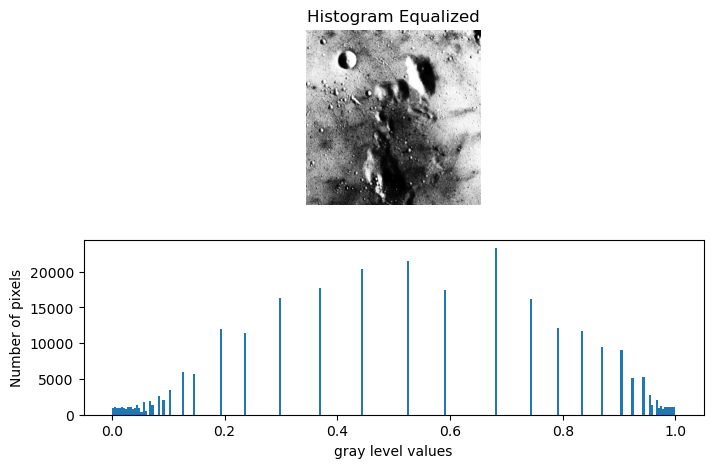

In [6]:
# Task2: Histogram Equalization of the moon image
img_eq = exposure.equalize_hist(img)

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_eq, cmap='gray')
plt.axis('off')
plt.title('Histogram Equalized')

fig.add_subplot(2, 1, 2)
plt.hist(img_eq.flat, bins=256, range=(0, 1))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()


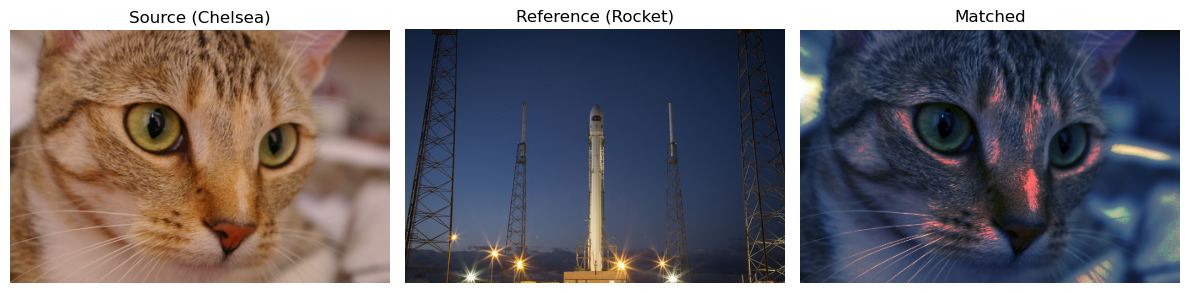

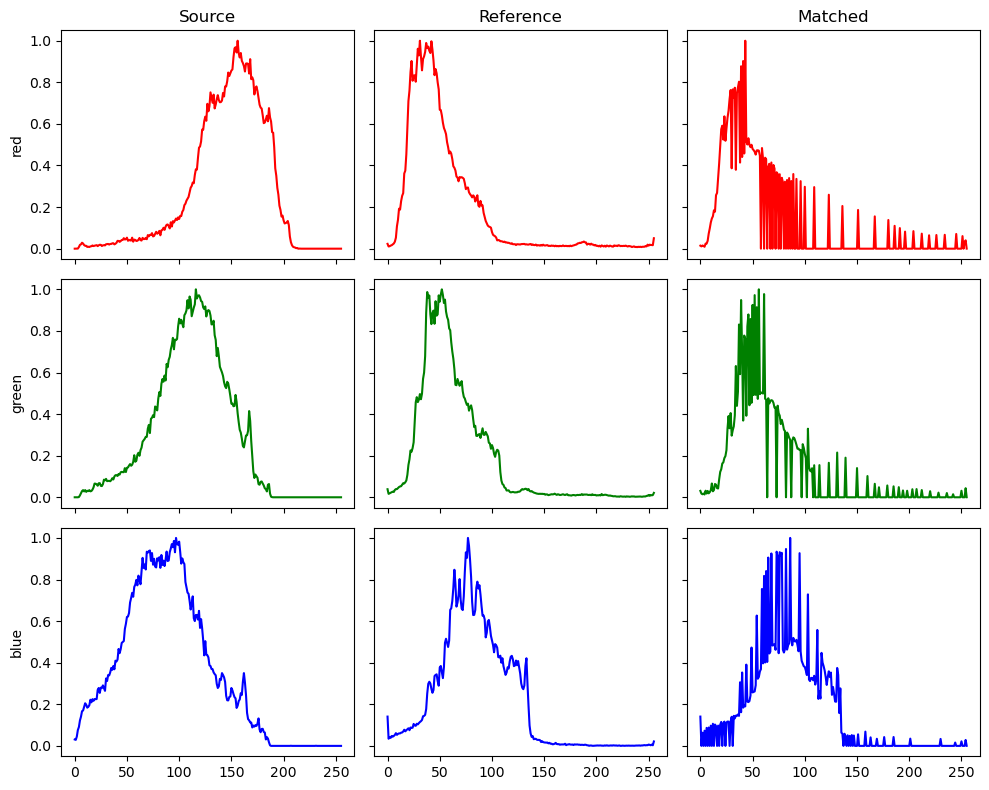

In [3]:
# Task3: Histogram Matching (rocket as reference, chelsea as source)
from skimage import data
from skimage import exposure
import matplotlib.pyplot as plt

# Load images
reference = data.rocket()
image = data.chelsea()

# Perform histogram matching (both images are RGB, so match channel by channel)
matched = exposure.match_histograms(image, reference, channel_axis=-1)

# Display the source, reference, and matched images
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, img_display, title in zip(
    axes, (image, reference, matched), ("Source (Chelsea)", "Reference (Rocket)", "Matched")
):
    ax.imshow(img_display)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

# Display the histogram of each color channel before and after matching
fig, axes = plt.subplots(3, 3, figsize=(10, 8), sharex=True, sharey=True)
for i, img_display in enumerate((image, reference, matched)):
    for c, c_color in enumerate(("red", "green", "blue")):
        img_hist, bins = exposure.histogram(img_display[..., c], source_range="dtype")
        axes[c, i].plot(bins, img_hist / img_hist.max(), color=c_color)
        axes[c, 0].set_ylabel(c_color)

for i, title in enumerate(("Source", "Reference", "Matched")):
    axes[0, i].set_title(title)

plt.tight_layout()
plt.show()
